In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from scipy import stats

df = pd.read_csv('/content/advertising.csv')

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(200, 4)
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [3]:
X = df[['TV']]
y = df['Sales']

In [4]:
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 6.974821488229891
Slope: 0.055464770469558874


In [5]:
y_pred = model.predict(X)

df['Predicted_Sales'] = y_pred
df['Residual'] = y - y_pred

df.head()

,TV,Radio,Newspaper,Sales,Predicted_Sales,Residual
0,230.1,37.8,69.2,22.1,19.737265,2.362735
1,44.5,39.3,45.1,10.4,9.443004,0.956996
2,17.2,45.9,69.3,12.0,7.928816,4.071184
3,151.5,41.3,58.5,16.5,15.377734,1.122266
4,180.8,10.8,58.4,17.9,17.002852,0.897148


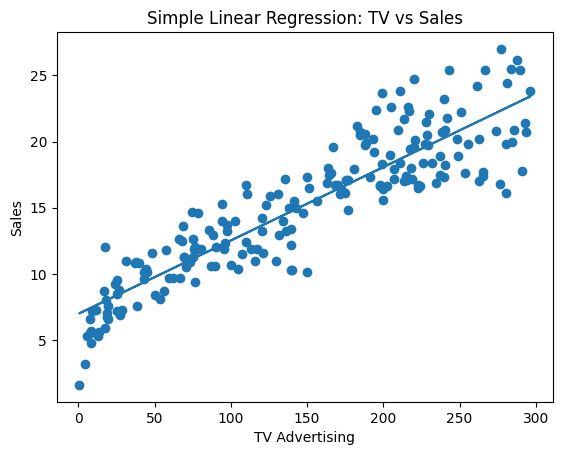

In [6]:
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Simple Linear Regression: TV vs Sales")
plt.show()

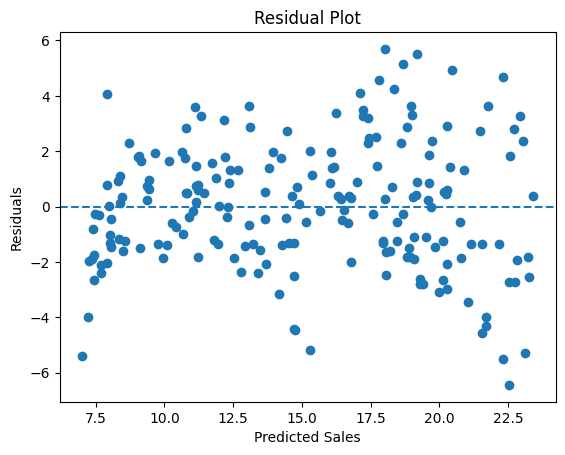

In [7]:
plt.scatter(y_pred, df['Residual'])
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

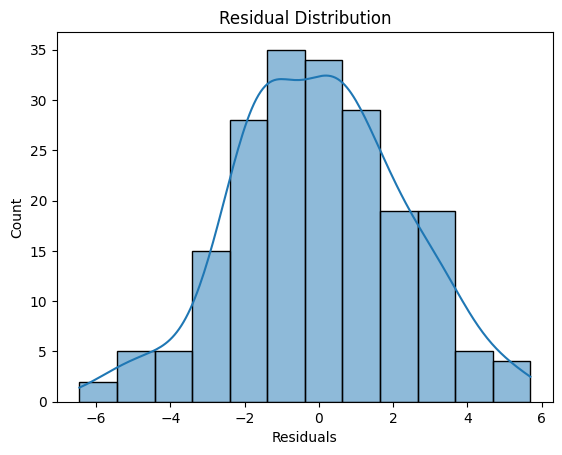

In [8]:
sns.histplot(df['Residual'], kde=True)
plt.xlabel("Residuals")
plt.title("Residual Distribution")
plt.show()

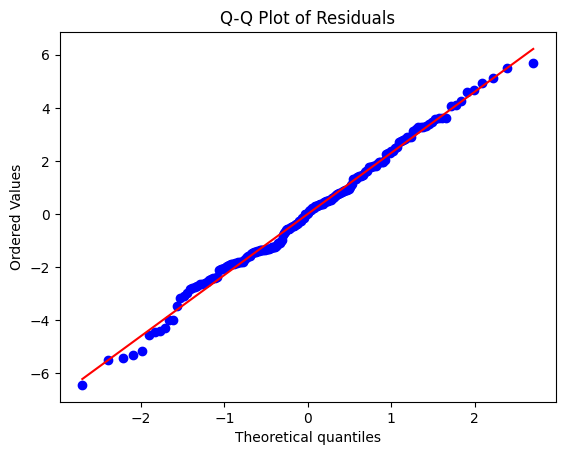

In [9]:
stats.probplot(df['Residual'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [10]:
Q1 = df['Residual'].quantile(0.25)
Q3 = df['Residual'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Residual'] < lower) | (df['Residual'] > upper)]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower limit =", lower)
print("Upper limit =", upper)
print("Number of outliers =", len(outliers))

Q1 = -1.4857247110748952
Q3 = 1.5042012744946458
IQR = 2.989925985569541
Lower limit = -5.970613689429206
Upper limit = 5.989090252848957
Number of outliers = 1


In [11]:
outliers[['TV', 'Sales', 'Predicted_Sales', 'Residual']]

,TV,Sales,Predicted_Sales,Residual
150,280.7,16.1,22.543783,-6.443783


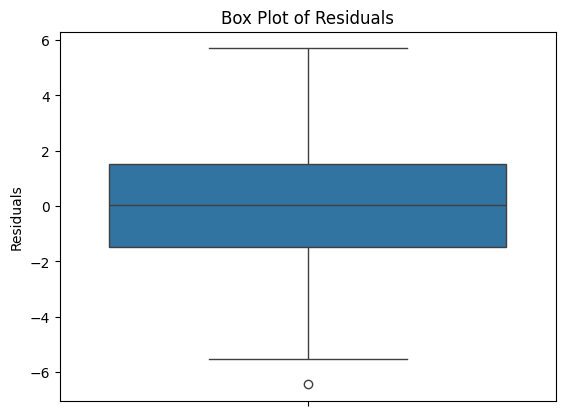

In [12]:
sns.boxplot(y=df['Residual'])
plt.title("Box Plot of Residuals")
plt.ylabel("Residuals")
plt.show()

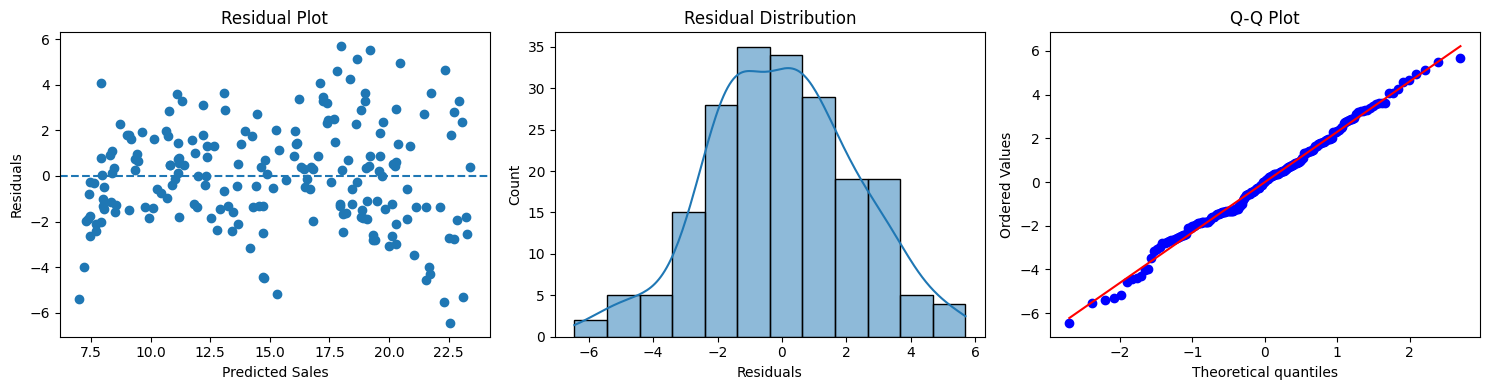

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Residual plot
ax[0].scatter(y_pred, df['Residual'])
ax[0].axhline(0, linestyle='--')
ax[0].set_title("Residual Plot")
ax[0].set_xlabel("Predicted Sales")
ax[0].set_ylabel("Residuals")

# Bell curve
sns.histplot(df['Residual'], kde=True, ax=ax[1])
ax[1].set_title("Residual Distribution")
ax[1].set_xlabel("Residuals")

# Q-Q plot
stats.probplot(df['Residual'], dist="norm", plot=ax[2])
ax[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

print("R² Score =", r2_score(y, y_pred))
print("MSE =", mean_squared_error(y, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y, y_pred)))

R² Score = 0.8121757029987414
MSE = 5.2177438977951285
RMSE = 2.2842381438447106


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

df = pd.read_csv('/content/Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [16]:
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(545, 13)
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.00

In [17]:
X = df[['area']]
y = df['price']

In [18]:
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 2387308.48239643
Slope: 461.97489427278344


In [19]:
y_pred = model.predict(X)

df['Predicted_Price'] = y_pred
df['Residual'] = y - y_pred

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,Predicted_Price,Residual
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,5.815162e+06,7.484838e+06
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,6.526604e+06,5.723396e+06
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,6.988578e+06,5.261422e+06
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,5.852120e+06,6.362880e+06
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,5.815162e+06,5.594838e+06


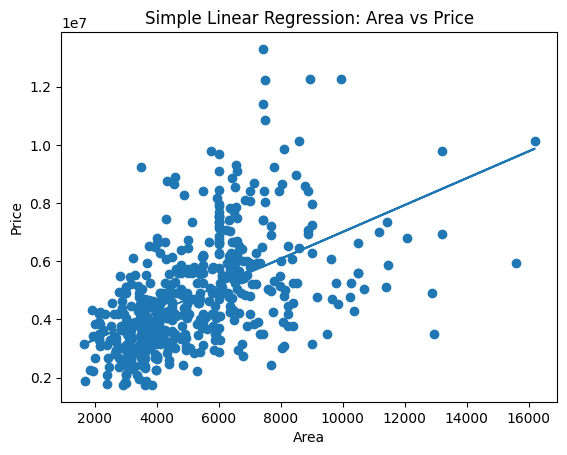

In [20]:
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Area vs Price")
plt.show()

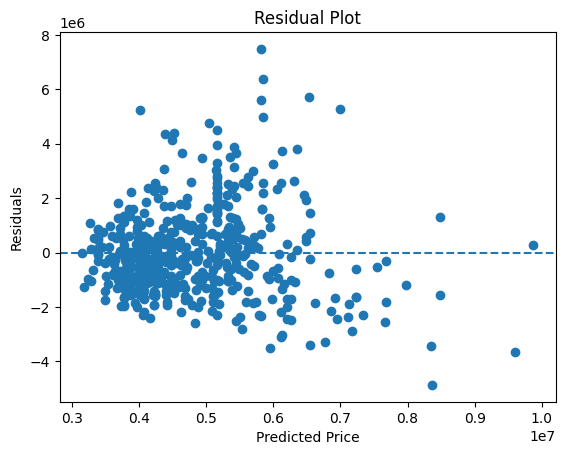

In [21]:
plt.scatter(y_pred, df['Residual'])
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

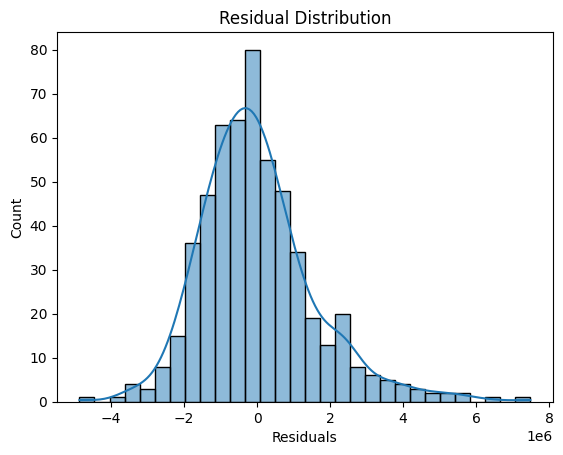

In [22]:
sns.histplot(df['Residual'], kde=True)
plt.xlabel("Residuals")
plt.title("Residual Distribution")
plt.show()

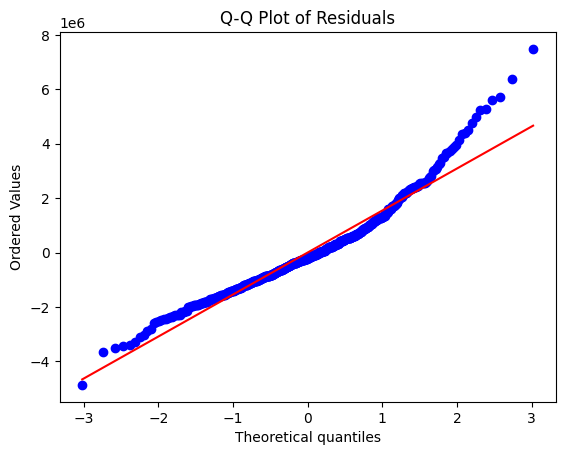

In [23]:
stats.probplot(df['Residual'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [24]:
Q1 = df['Residual'].quantile(0.25)
Q3 = df['Residual'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Residual'] < lower) | (df['Residual'] > upper)]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower limit =", lower)
print("Upper limit =", upper)
print("Number of outliers =", len(outliers))

Q1 = -1022228.2246190384
Q3 = 683027.0885305395
IQR = 1705255.313149578
Lower limit = -3580111.1943434053
Upper limit = 3240910.0582549064
Number of outliers = 24


In [25]:
outliers[['area', 'price', 'Predicted_Price', 'Residual']]

,area,price,Predicted_Price,Residual
0,7420,13300000,5.815162e+06,7.484838e+06
1,8960,12250000,6.526604e+06,5.723396e+06
2,9960,12250000,6.988578e+06,5.261422e+06
3,7500,12215000,5.852120e+06,6.362880e+06
4,7420,11410000,5.815162e+06,5.594838e+06
5,7500,10850000,5.852120e+06,4.997880e+06
6,8580,10150000,6.351053e+06,3.798947e+06
8,8100,9870000,6.129305e+06,3.740695e+06
9,5750,9800000,5.043664e+06,4.756336e+06
11,6000,9681000,5.159158e+06,4.521842e+06


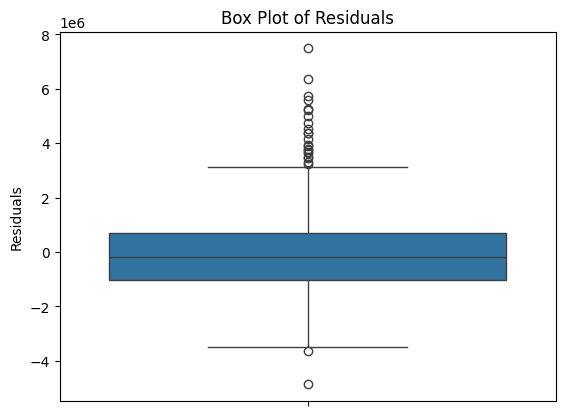

In [26]:
sns.boxplot(y=df['Residual'])
plt.title("Box Plot of Residuals")
plt.ylabel("Residuals")
plt.show()

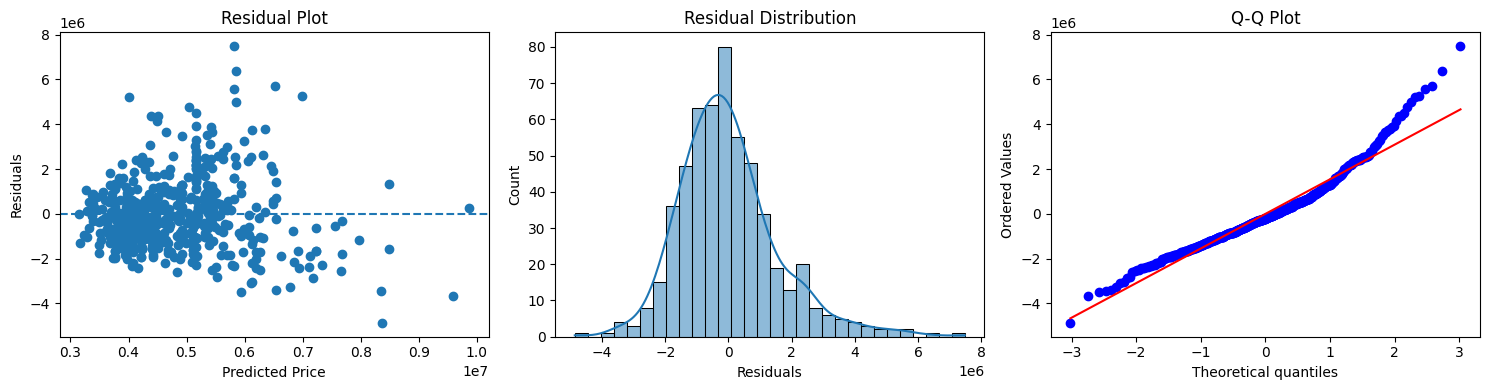

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Residual plot
ax[0].scatter(y_pred, df['Residual'])
ax[0].axhline(0, linestyle='--')
ax[0].set_title("Residual Plot")
ax[0].set_xlabel("Predicted Price")
ax[0].set_ylabel("Residuals")

# Bell curve
sns.histplot(df['Residual'], kde=True, ax=ax[1])
ax[1].set_title("Residual Distribution")
ax[1].set_xlabel("Residuals")

# Q-Q plot
stats.probplot(df['Residual'], dist="norm", plot=ax[2])
ax[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

print("R² Score =", r2_score(y, y_pred))
print("MSE =", mean_squared_error(y, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y, y_pred)))

R² Score = 0.2872931546811469
MSE = 2488861398180.6567
RMSE = 1577612.5627607866
